
# IN GOD WE TRUST


In [2]:
import numpy as np 

import pandas as pd 

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler


from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso, Ridge, ElasticNet


from sklearn.svm import SVC, SVR


from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.ensemble import (
    
    AdaBoostRegressor,
    
    AdaBoostClassifier,
    
    BaggingClassifier,
    
    BaggingRegressor, 
    
    RandomForestRegressor,
    
    RandomForestClassifier,
    
    GradientBoostingClassifier,
    
    GradientBoostingRegressor
     )


from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor


from sklearn.metrics import (
    r2_score,
    f1_score,
    accuracy_score,
    precision_score,
    mean_absolute_error,
    mean_squared_error,
    
)

from sklearn.pipeline import Pipeline


from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    cross_val_score,
    RandomizedSearchCV,
    GridSearchCV,)

In [3]:
address = r"D:\Data science\Source code\Global Superstore.csv"
csv_file = pd.read_csv(address)

df = pd.DataFrame(csv_file)

In [4]:
df

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,00:00.0,CA-2014-109701,...,69,Corporate,00:00.0,Same Day,5.15,California,Binders,2014,North America,49
51286,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,00:00.0,CA-2014-109701,...,9,Corporate,00:00.0,Same Day,0.44,California,Binders,2014,North America,49
51287,Office Supplies,Los Angeles,United States,HR-147704,Hallie Redmond,0.2,US,1,00:00.0,CA-2014-106964,...,12,Home Office,00:00.0,First Class,0.31,California,Binders,2014,North America,51
51288,Office Supplies,Los Angeles,United States,RM-196754,Robert Marley,0.2,US,1,00:00.0,CA-2014-145219,...,90,Home Office,00:00.0,First Class,15.95,California,Binders,2014,North America,52


In [5]:
df.describe().round(2)

,Discount,ji_lu-shu,Profit,Quantity,Row ID,Sales,Shipping Cost,Year,weeknum
count,51290.00,51290.0,51290.00,51290.00,51290.00,51290.00,51290.00,51290.00,51290.00
mean,0.14,1.0,28.61,3.48,25645.50,246.50,26.38,2012.78,31.29
std,0.21,0.0,174.34,2.28,14806.29,487.57,57.30,1.10,14.43
min,0.00,1.0,-6599.98,1.00,1.00,0.00,0.00,2011.00,1.00
25%,0.00,1.0,0.00,2.00,12823.25,31.00,2.61,2012.00,20.00
50%,0.00,1.0,9.24,3.00,25645.50,85.00,7.79,2013.00,33.00
75%,0.20,1.0,36.81,5.00,38467.75,251.00,24.45,2014.00,44.00
max,0.85,1.0,8399.98,14.00,51290.00,22638.00,933.57,2014.00,53.00


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  str    
 1   City            51290 non-null  str    
 2   Country         51290 non-null  str    
 3   Customer ID     51290 non-null  str    
 4   Customer Name   51290 non-null  str    
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  str    
 7   ji_lu-shu       51290 non-null  int64  
 8   Order Date      51290 non-null  str    
 9   Order ID        51290 non-null  str    
 10  Order Priority  51290 non-null  str    
 11  Product ID      51290 non-null  str    
 12  Product Name    51290 non-null  str    
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  str    
 16  Row ID          51290 non-null  int64  
 17  Sales           51290 non-null  int64  
 1

In [7]:
df["Discount"].value_counts(ascending=False)

Discount
0.000    29009
0.200     4998
0.100     4068
0.400     3177
0.600     2006
0.700     1786
0.500     1633
0.170      735
0.470      725
0.150      541
0.002      461
0.270      388
0.300      340
0.450      327
0.800      316
0.250      198
0.070      150
0.350      122
0.402      104
0.370       74
0.202       41
0.320       27
0.602       23
0.650       17
0.570       12
0.550       10
0.850        2
Name: count, dtype: int64

# Data preprocessing

## Dropping Useless Features

Some columns in the dataset do not provide meaningful information for analysis or machine learning models. These columns are either identifiers or contain constant / non-informative values.

To simplify the dataset and reduce noise, we remove them using the following code:


In [8]:
# Droping useless features
# df.drop(columns=["Order Date"], inplace=True)
# df.drop(columns="Season", inplace=True)
# df.drop(columns="weeknum", inplace=True)
# df.drop(columns="Row ID", inplace=True)

In [9]:
country = df["Country"].value_counts()
country_list = []
for c in country.index:
    
    country_list.append(c)
    
print(len(country_list))

147


In [10]:
df["Product Name"].nunique()

3788

## Dropping the Ship Date Column

After examining the `Ship Date` column, it was found that all rows contain the same value:


In [11]:
df["Ship Date"].value_counts()

Ship Date
00:00.0    51290
Name: count, dtype: int64


Since there is no variation in this column, it does not provide any useful information for analysis or modeling. A feature with a single repeated value has zero predictive power.

Therefore, the column is removed from the dataset:

In [12]:
df.drop(columns="Ship Date", inplace=True)

In [13]:
for col in df.select_dtypes(include="str"):
    print(col, df[col].nunique())

Category 3
City 3636
Country 147
Customer ID 4873
Customer Name 795
Market 7
Order Date 1
Order ID 25035
Order Priority 4
Product ID 10292
Product Name 3788
Region 13
Segment 3
Ship Mode 4
State 1094
Sub-Category 17
Market2 6


In [14]:
df[["Market", "Market2"]].value_counts()

Market  Market2      
APAC    APAC             11002
LATAM   LATAM            10294
EU      EU               10000
US      North America     9994
EMEA    EMEA              5029
Africa  Africa            4587
Canada  North America      384
Name: count, dtype: int64

## Converting Date Columns to Datetime Format

In the original dataset, the `Order Date` and `Ship Date` columns were stored as strings (object type).  
This prevents us from performing any time-based operations such as subtraction, extraction of year/month, or calculating shipping duration.

To fix this, we convert both columns into pandas datetime format using `pd.to_datetime()`:


In [15]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
# df["Ship Date"] = pd.to_datetime(df["Ship Date"])

## Creating a Seasonal Feature from Week Number

To capture seasonal patterns in the dataset, a new feature called `Season` is created based on the `weeknum` column.

The idea is to group weeks of the year into four meaningful business seasons:

- Winter: Weeks 1–13  
- Spring: Weeks 14–26  
- Summer: Weeks 27–39  
- Fall: Weeks 40–52  

This transformation is done using `np.select()`, which allows us to apply multiple conditions efficiently:


In [16]:
df["Season"] = np.select([
        (df["weeknum"] >= 1) & (df["weeknum"] <=13),
        (df["weeknum"] >= 14) & (df["weeknum"] <=26),
        (df["weeknum"] >= 27) & (df["weeknum"] <=39),
        (df["weeknum"] >= 40) & (df["weeknum"] <=53),
    ],
                         ["winter", "spring", "summer", "fall"],
                         default="unknown")

In [17]:
pd.crosstab(df["Market"], df["Market2"])

Market2,APAC,Africa,EMEA,EU,LATAM,North America
Market,,,,,,
APAC,11002,0,0,0,0,0
Africa,0,4587,0,0,0,0
Canada,0,0,0,0,0,384
EMEA,0,0,5029,0,0,0
EU,0,0,0,10000,0,0
LATAM,0,0,0,0,10294,0
US,0,0,0,0,0,9994


## Dropping Redundant Feature: Market2

After analyzing the relationship between `Market` and `Market2`, it was found that there is a one-to-one mapping between these two columns. Each value in `Market` corresponds to exactly one category in `Market2`.

This means that `Market2` does not provide any additional information beyond what is already contained in `Market`. Therefore, it is considered a redundant feature.

To simplify the dataset and avoid unnecessary duplication of information, `Market2` is removed:


In [18]:
df.drop(columns=["Market2"], inplace=True)

## Creating a Clean Dataset for Machine Learning

To prepare the data for modeling, a separate dataset is created that contains only relevant and meaningful features.

The original dataset is kept for exploration and analysis, while this new dataset is designed specifically for machine learning tasks.

This ML-focused dataset includes engineered features such as `Season`, along with other transformed numerical and categorical variables that better capture patterns in the data.

Irrelevant columns such as identifiers, high-cardinality text fields, and redundant features are excluded to reduce noise and improve model performance.

### Why this step is important:

- Separates analysis from modeling workflow
- Removes unnecessary and noisy features
- Improves model efficiency and generalization
- Keeps the dataset structured and easier to work with

In [19]:
df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Row ID,Sales,Segment,Ship Mode,Shipping Cost,State,Sub-Category,Year,weeknum,Season
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2026-06-12,CA-2011-130813,...,36624,19,Consumer,Second Class,4.37,California,Paper,2011,2,winter
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2026-06-12,CA-2011-148614,...,37033,19,Consumer,Standard Class,0.94,California,Paper,2011,4,winter
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2026-06-12,CA-2011-118962,...,31468,21,Consumer,Standard Class,1.81,California,Paper,2011,32,summer
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2026-06-12,CA-2011-118962,...,31469,111,Consumer,Standard Class,4.59,California,Paper,2011,32,summer
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2026-06-12,CA-2011-146969,...,32440,6,Consumer,Standard Class,1.32,California,Paper,2011,40,fall


In [20]:
df_ml = df[["Sales", "Market", "Quantity", "Shipping Cost","Year","Segment","Season","Order Priority","Category","Profit"]].copy()
df_ml = pd.get_dummies(df_ml, columns=["Segment","Season","Order Priority","Category", "Market"], drop_first=True).astype(int)

In [21]:
df_ml.drop(columns="Profit", inplace=True)

In [22]:
df_ml.describe()

,Sales,Quantity,Shipping Cost,Year,Segment_Corporate,Segment_Home Office,Season_spring,Season_summer,Season_winter,Order Priority_High,Order Priority_Low,Order Priority_Medium,Category_Office Supplies,Category_Technology,Market_Africa,Market_Canada,Market_EMEA,Market_EU,Market_LATAM,Market_US
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.498440,3.476545,25.883057,2012.777208,0.300819,0.18216,0.234783,0.273192,0.148937,0.302223,0.047261,0.573855,0.609729,0.197719,0.089433,0.007487,0.098050,0.194970,0.200702,0.194853
std,487.567175,2.278766,57.297507,1.098931,0.458619,0.38598,0.423867,0.445603,0.356030,0.459226,0.212198,0.494520,0.487816,0.398283,0.285370,0.086203,0.297386,0.396181,0.400529,0.396091
min,0.000000,1.000000,0.000000,2011.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,2.000000,2.000000,2012.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,85.000000,3.000000,7.000000,2013.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,251.000000,5.000000,24.000000,2014.000000,1.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,22638.000000,14.000000,933.000000,2014.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [23]:
df_ml["Discount"] = df["Discount"]

In [24]:
df_ml["Target"] = df["Profit"]

In [25]:
df["weeknum"].value_counts().sort_index()

weeknum
1      381
2      550
3      604
4      568
5      568
6      527
7      592
8      536
9      543
10     679
11     697
12     745
13     649
14     711
15     724
16     742
17     714
18     692
19     936
20     821
21     812
22     891
23    1153
24    1337
25    1228
26    1281
27     837
28     728
29     664
30     720
31     856
32    1147
33    1188
34    1166
35    1119
36    1358
37    1350
38    1453
39    1426
40    1118
41     940
42    1017
43    1046
44    1053
45    1508
46    1524
47    1527
48    1441
49    1440
50    1378
51    1381
52    1461
53     763
Name: count, dtype: int64

In [26]:
df_ml

,Sales,Quantity,Shipping Cost,Year,Segment_Corporate,Segment_Home Office,Season_spring,Season_summer,Season_winter,Order Priority_High,...,Category_Office Supplies,Category_Technology,Market_Africa,Market_Canada,Market_EMEA,Market_EU,Market_LATAM,Market_US,Discount,Target
0,19,3,4,2011,0,0,0,0,1,1,...,1,0,0,0,0,0,0,1,0.0,9.3312
1,19,2,0,2011,0,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0.0,9.2928
2,21,3,1,2011,0,0,0,1,0,0,...,1,0,0,0,0,0,0,1,0.0,9.8418
3,111,2,4,2011,0,0,0,1,0,0,...,1,0,0,0,0,0,0,1,0.0,53.2608
4,6,1,1,2011,0,0,0,0,0,1,...,1,0,0,0,0,0,0,1,0.0,3.1104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,69,2,5,2014,1,0,0,0,0,1,...,1,0,0,0,0,0,0,1,0.2,22.5732
51286,9,6,0,2014,1,0,0,0,0,1,...,1,0,0,0,0,0,0,1,0.2,3.1584
51287,12,2,0,2014,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0.2,4.2804
51288,90,3,15,2014,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0.2,33.9300


# data visualization

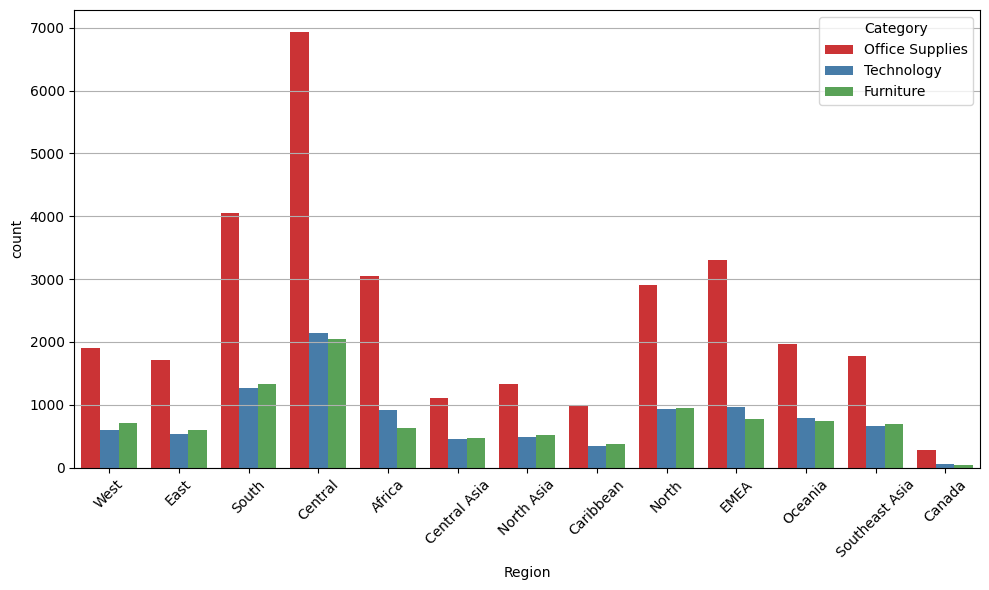

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x ="Region", palette="Set1", hue="Category")
plt.xticks(rotation= 45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

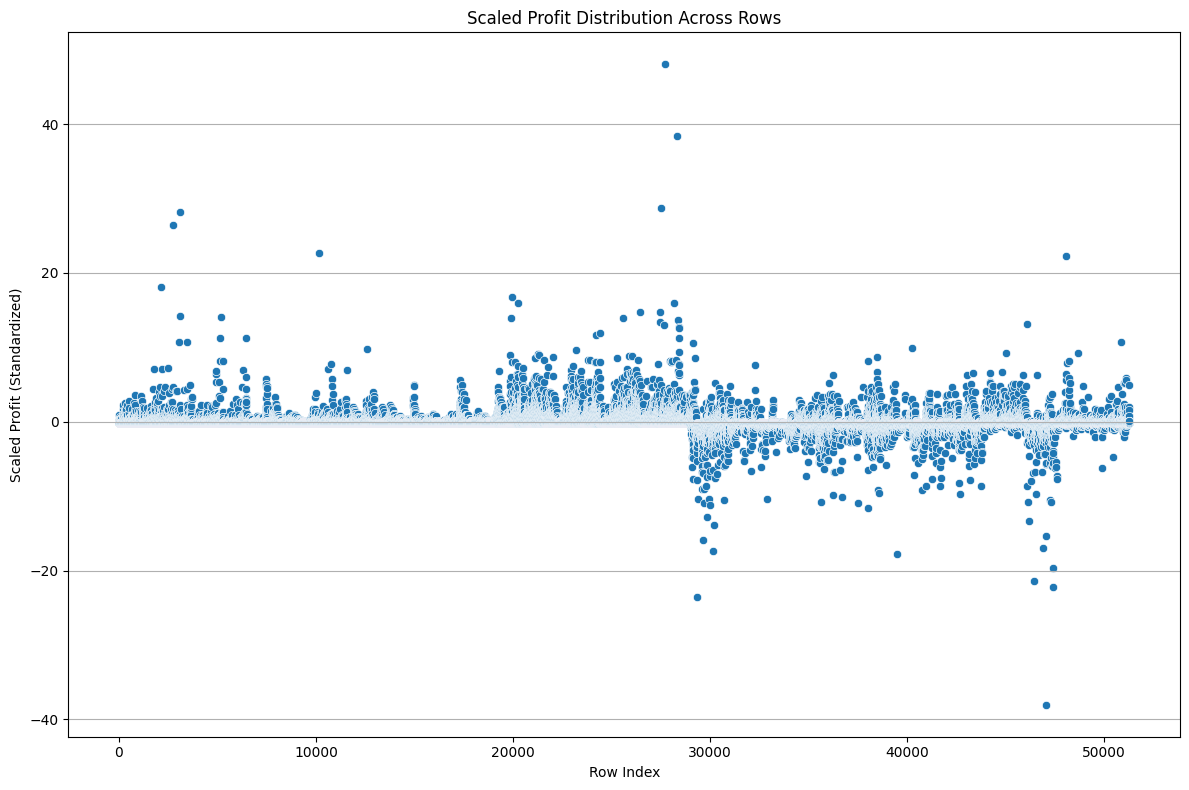

In [28]:
plt.figure(figsize=(12,8))

scaler = StandardScaler()

scaled_profit = scaler.fit_transform(df[["Profit"]]).flatten()

sns.scatterplot(data=df, x = df.index, y= scaled_profit)
plt.title("Scaled Profit Distribution Across Rows")
plt.xlabel("Row Index")
plt.ylabel("Scaled Profit (Standardized)")



sns.lineplot()
sns.lineplot()

plt.grid(axis="y")
plt.tight_layout()
plt.show()

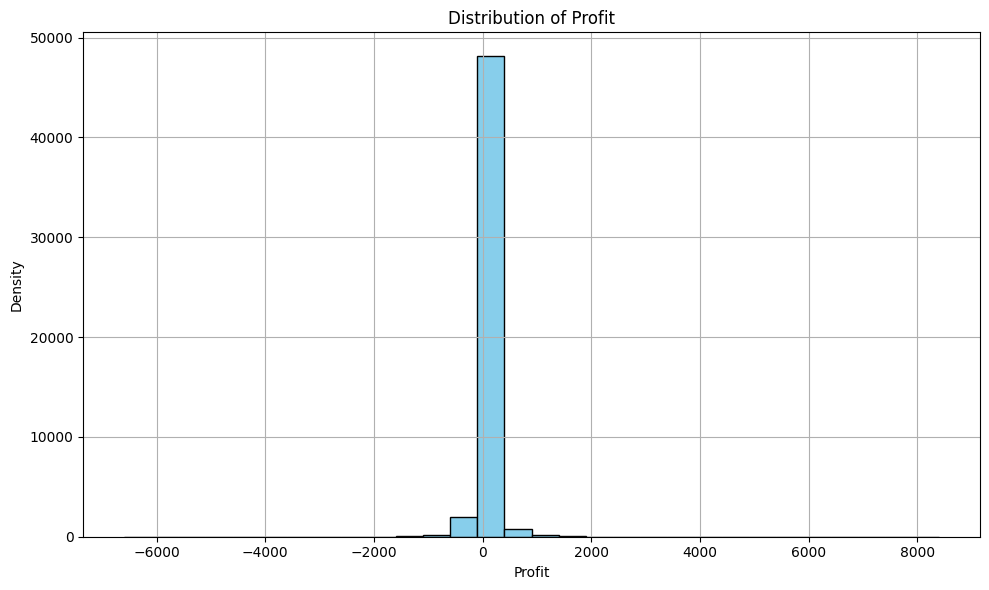

In [29]:
plt.figure(figsize=(10,6))

plt.hist(df["Profit"], bins=30 ,density=False, edgecolor="black", color= "skyblue")

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Density")

plt.grid()
plt.tight_layout()
plt.show()

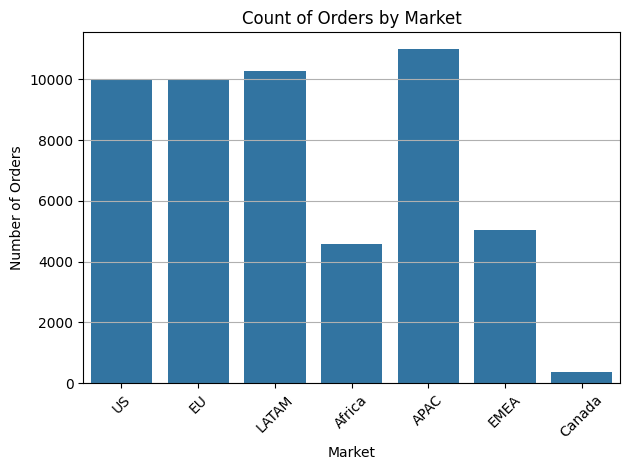

In [30]:
sns.countplot(data= df, x= "Market")

plt.title("Count of Orders by Market")
plt.xlabel("Market")
plt.ylabel("Number of Orders")

plt.xticks(rotation = 45)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

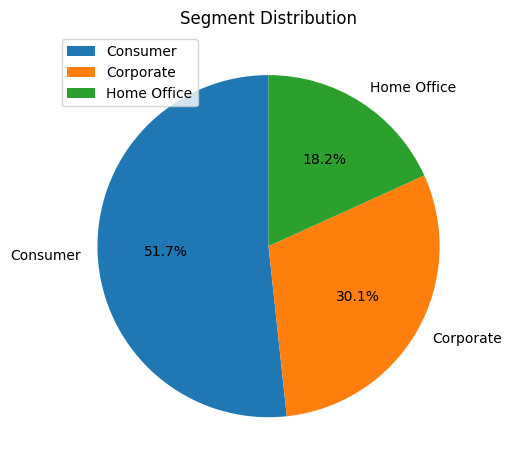

In [31]:
plt.figure()

plt.pie(df["Segment"].value_counts(),
        explode= [0, 0, 0],
        labels= df["Segment"].value_counts().index,
        startangle= 90,
        autopct = "%1.1f%%")


plt.title("Segment Distribution")
plt.legend()
plt.tight_layout()

plt.show()

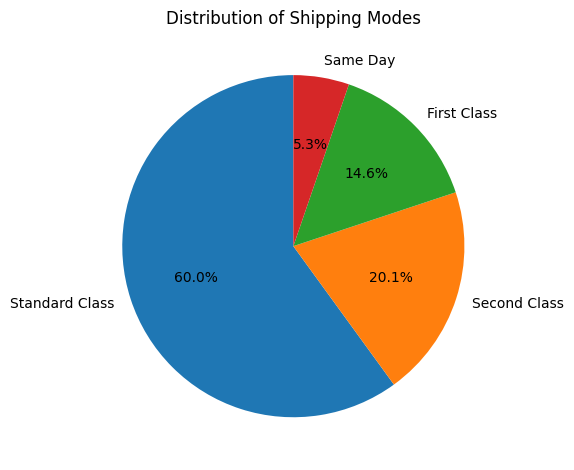

In [32]:
plt.figure()


plt.pie(df["Ship Mode"].value_counts(),
        labels=df["Ship Mode"].value_counts().index,
        autopct="%1.1f%%", 
        startangle=90)


plt.title("Distribution of Shipping Modes")
plt.tight_layout()
plt.show()

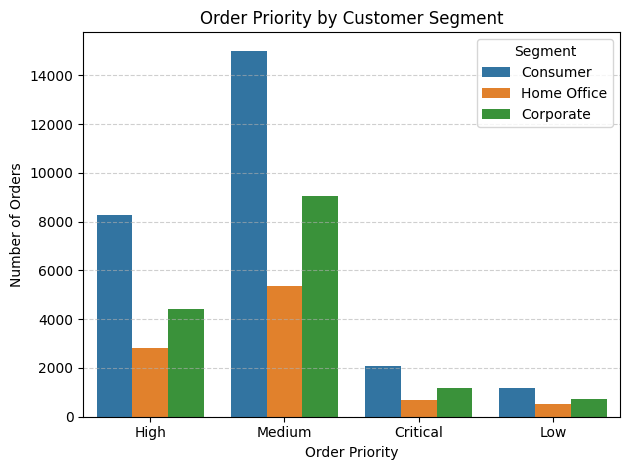

In [33]:
sns.countplot(data= df, x= "Order Priority", hue = "Segment")
plt.title("Order Priority by Customer Segment")
plt.xlabel("Order Priority")
plt.ylabel("Number of Orders")

plt.grid(axis="y", linestyle="--", alpha = 0.6)
plt.tight_layout()

plt.show()

In [34]:
# top five cities
top_five_City = df["City"].value_counts(ascending=False).head(5)

In [35]:
print(top_five_City.values.sum())

3152


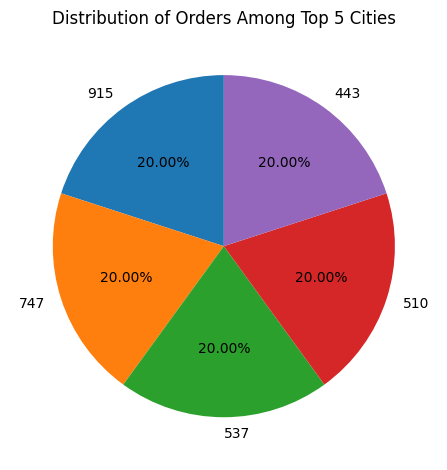

In [36]:
plt.figure()

plt.pie(top_five_City.value_counts(), 
        labels=top_five_City.value_counts().index,
        startangle = 90,
        autopct= "%1.2f%%"
        )
plt.title("Distribution of Orders Among Top 5 Cities")
plt.tight_layout()
plt.show()

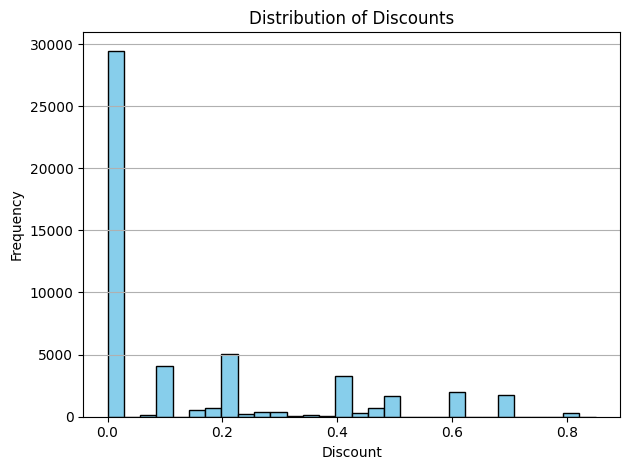

In [37]:
plt.figure()

plt.hist(df["Discount"], bins=30, edgecolor="black", color="skyblue")
plt.title("Distribution of Discounts")
plt.xlabel("Discount")
plt.ylabel("Frequency")

plt.grid(axis="y")
plt.tight_layout()

plt.show()

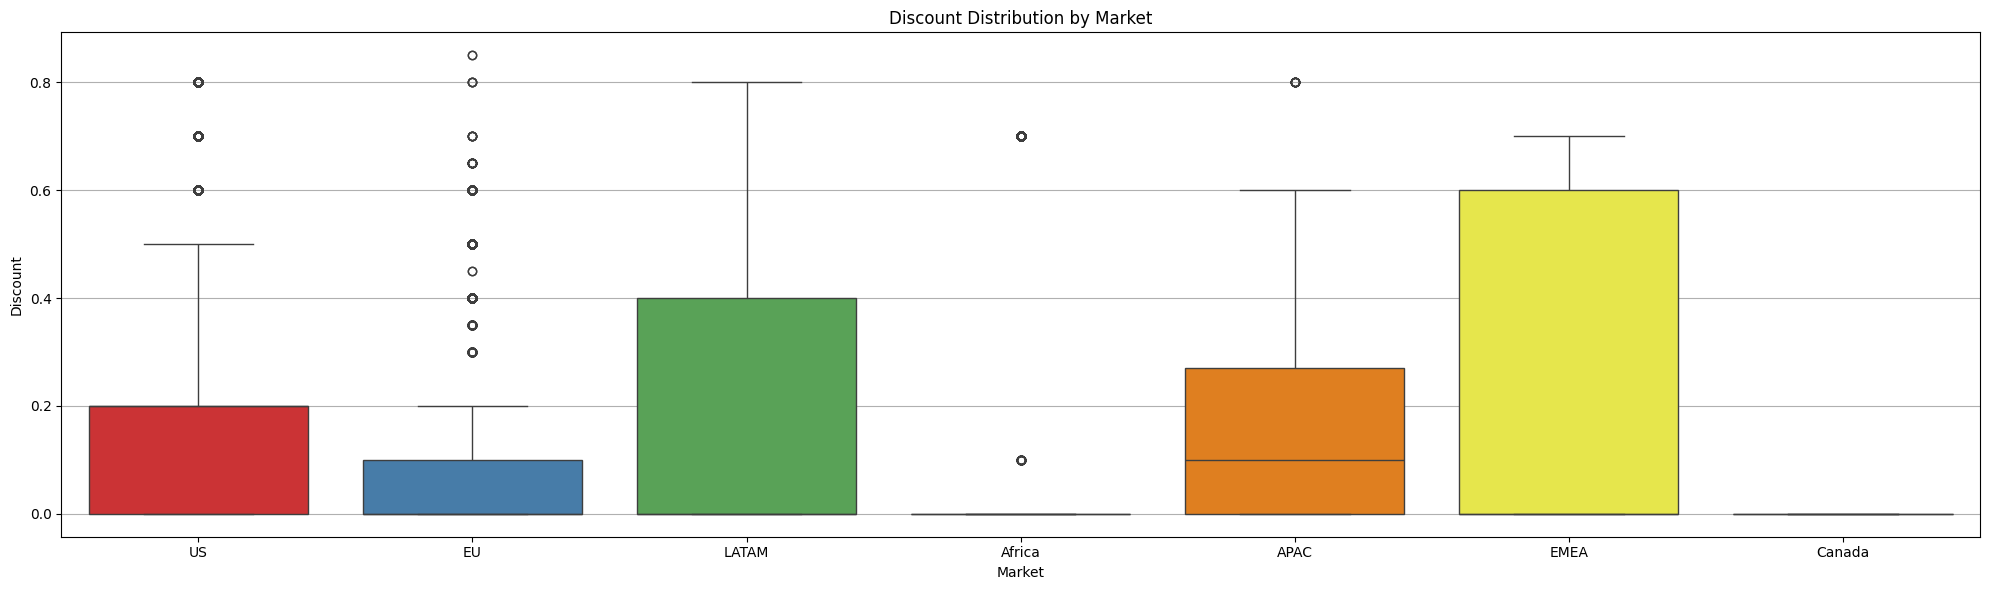

In [38]:
plt.figure(figsize=(20,6))

sns.boxplot(data=df, x="Market", y="Discount", hue="Market", palette="Set1")

plt.title("Discount Distribution by Market")
plt.xlabel("Market")
plt.ylabel("Discount")

plt.grid(axis="y")
plt.tight_layout()
plt.show()

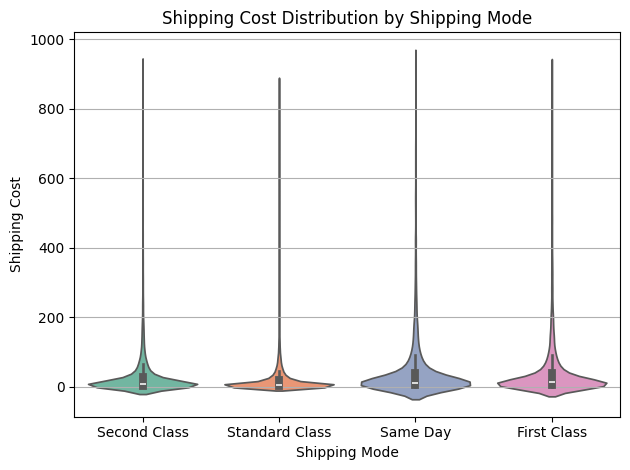

In [39]:
plt.figure()

sns.violinplot(data= df, x= "Ship Mode", y= "Shipping Cost", palette="Set2", hue="Ship Mode" ,legend=False)

plt.title("Shipping Cost Distribution by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Shipping Cost")


plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [40]:
df_ml

,Sales,Quantity,Shipping Cost,Year,Segment_Corporate,Segment_Home Office,Season_spring,Season_summer,Season_winter,Order Priority_High,...,Category_Office Supplies,Category_Technology,Market_Africa,Market_Canada,Market_EMEA,Market_EU,Market_LATAM,Market_US,Discount,Target
0,19,3,4,2011,0,0,0,0,1,1,...,1,0,0,0,0,0,0,1,0.0,9.3312
1,19,2,0,2011,0,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0.0,9.2928
2,21,3,1,2011,0,0,0,1,0,0,...,1,0,0,0,0,0,0,1,0.0,9.8418
3,111,2,4,2011,0,0,0,1,0,0,...,1,0,0,0,0,0,0,1,0.0,53.2608
4,6,1,1,2011,0,0,0,0,0,1,...,1,0,0,0,0,0,0,1,0.0,3.1104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,69,2,5,2014,1,0,0,0,0,1,...,1,0,0,0,0,0,0,1,0.2,22.5732
51286,9,6,0,2014,1,0,0,0,0,1,...,1,0,0,0,0,0,0,1,0.2,3.1584
51287,12,2,0,2014,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0.2,4.2804
51288,90,3,15,2014,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0.2,33.9300


# Modeling (Linear regression, Lasso, Elastic, )

In [41]:
X = df_ml.drop(columns="Target")
y = df_ml["Target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
lr = LinearRegression()

model = lr.fit(X_train, y_train)

y_pred = model.predict(X_test)


# Evaluation

In [43]:
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"R2 score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

MSE: 25744.38157524816
MAE: 60.473898741590766
R2 score: 0.12378707811274225
RMSE: 160.45055803969072


In [44]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2s = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [45]:
eva_result = {
    "Metric": ["MSE", "MAE", "R2 Score", "RMSE"],
    "Value": [mse, mae, r2s, rmse]
}
df_eva = pd.DataFrame(eva_result)

In [46]:
df_eva.round(2)

,Metric,Value
0,MSE,25744.38
1,MAE,60.47
2,R2 Score,0.12
3,RMSE,160.45


In [47]:
L1 = Lasso(alpha=1)
model_lasso = L1.fit(X_train, y_train)

y_pre_lasso = model_lasso.predict(X_test)
print(y_pre_lasso)
print("-----------")
print(model_lasso.coef_)

[-32.38563979  16.23395139  28.69206539 ... -14.11666516 -80.57216106
 -48.16237156]
-----------
[   0.23167857   -4.65541496   -0.36748193    0.           -0.
    0.            0.           -0.           -0.            0.
    0.           -1.54113701   26.65829429    7.50253352    0.
    0.            0.           -3.56213247    0.            2.34667707
 -195.07023007]


In [48]:
r2lasso = r2_score(y_test, y_pre_lasso)
r2lasso

0.12803938760864164

In [49]:
L2 = Ridge(alpha=1)

model_ridge = L2.fit(X_train, y_train)

y_pre_ridge = model_ridge.predict(X_test)

print(model_ridge.coef_)

[ 2.36195198e-01 -4.85239171e+00 -4.05547182e-01  1.27570140e-01
 -8.52363617e-01  6.40450214e-01 -4.33130810e-02 -1.64582108e+00
 -9.35795449e-01 -1.46256819e+01 -1.88006356e+01 -1.86696629e+01
  3.84024777e+01  2.25024248e+01  1.86061967e+00 -7.88536392e+00
  2.58186757e+00 -9.04174744e+00  1.36539481e+00  8.94796597e+00
 -2.17375422e+02]


In [50]:
print(r2_score(y_test, y_pre_ridge))

0.12378082427729065


In [51]:
L3 = ElasticNet(alpha=0.5)

model_elastic = L3.fit(X_train, y_train)

y_pred_en5 = model_elastic.predict(X_test)

print(model_elastic.coef_)

[ 2.34995970e-01 -4.57504981e+00 -3.64400257e-01  3.84282768e-02
 -0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -2.49571543e+00
  1.46777691e+01  1.40234913e+00  0.00000000e+00  0.00000000e+00
 -9.21389721e-01 -1.66999790e-02  7.52554920e-02  1.92303071e+00
 -3.22629797e+01]


In [52]:
print(r2_score(y_test, y_pred_en5))

0.05902922987280679


In [53]:
print(r2_score(y_test, y_pred_en5))

0.05902922987280679


In [54]:
regularization = {
    "Metric": ["Lasso", "Ridge", "Elasstic"],
    "Value": [y_pre_lasso, y_pre_ridge, y_pred_en5],
}
df_reg = pd.DataFrame(regularization)


In [55]:
L3 = ElasticNet(alpha=0.8)

model_elastic = L3.fit(X_train, y_train)

y_pred_en1 = model_elastic.predict(X_test)

print(model_elastic.coef_)

[  0.23394824  -4.33090536  -0.36354153   0.          -0.
   0.          -0.          -0.          -0.           0.
  -0.          -1.69599552  10.67283154   0.           0.
   0.          -0.40820259  -0.           0.           1.04533909
 -21.10375087]


In [56]:
print(r2_score(y_test, y_pred_en1))

0.051720318284473654


In [57]:
L3 = ElasticNet(alpha=0.2, l1_ratio=0.8)

model_elastic = L3.fit(X_train, y_train)

y_pred_en = model_elastic.predict(X_test)

print(model_elastic.coef_)

[ 2.36244998e-01 -4.93751565e+00 -3.72333544e-01  6.59676008e-02
 -1.94768974e-01  0.00000000e+00  0.00000000e+00 -4.55028441e-02
 -0.00000000e+00 -2.07225777e+00 -2.12343310e+00 -5.98697907e+00
  2.98840064e+01  1.19311785e+01  0.00000000e+00  0.00000000e+00
 -5.93100737e-01 -3.36577154e+00  8.44520853e-01  5.42465754e+00
 -1.12589264e+02]


In [58]:
lasso_feature = pd.DataFrame({"feature": X_train.columns,
                              "Coef": model_lasso.coef_})

In [59]:
lasso_feature 

,feature,Coef
0,Sales,0.231679
1,Quantity,-4.655415
2,Shipping Cost,-0.367482
3,Year,0.000000
4,Segment_Corporate,-0.000000
5,Segment_Home Office,0.000000
6,Season_spring,0.000000
7,Season_summer,-0.000000
8,Season_winter,-0.000000
9,Order Priority_High,0.000000


In [60]:
zero_features = lasso_feature[lasso_feature["Coef"] == 0]
zero_features

,feature,Coef
3,Year,0.0
4,Segment_Corporate,-0.0
5,Segment_Home Office,0.0
6,Season_spring,0.0
7,Season_summer,-0.0
8,Season_winter,-0.0
9,Order Priority_High,0.0
10,Order Priority_Low,0.0
14,Market_Africa,0.0
15,Market_Canada,0.0


In [61]:
name_feature = lasso_feature[lasso_feature["Coef"] != 0]["feature"]
name_feature

0                        Sales
1                     Quantity
2                Shipping Cost
11       Order Priority_Medium
12    Category_Office Supplies
13         Category_Technology
17                   Market_EU
19                   Market_US
20                    Discount
Name: feature, dtype: str

In [62]:
zero_feature = lasso_feature[lasso_feature["Coef"] == 0]["feature"]
zero_feature.values

<StringArray>
[               'Year',   'Segment_Corporate', 'Segment_Home Office',
       'Season_spring',       'Season_summer',       'Season_winter',
 'Order Priority_High',  'Order Priority_Low',       'Market_Africa',
       'Market_Canada',         'Market_EMEA',        'Market_LATAM']
Length: 12, dtype: str

In [63]:
df_ml.drop(columns=zero_feature.values, inplace=True)

In [64]:
df_ml

,Sales,Quantity,Shipping Cost,Order Priority_Medium,Category_Office Supplies,Category_Technology,Market_EU,Market_US,Discount,Target
0,19,3,4,0,1,0,0,1,0.0,9.3312
1,19,2,0,1,1,0,0,1,0.0,9.2928
2,21,3,1,1,1,0,0,1,0.0,9.8418
3,111,2,4,1,1,0,0,1,0.0,53.2608
4,6,1,1,0,1,0,0,1,0.0,3.1104
...,...,...,...,...,...,...,...,...,...,...
51285,69,2,5,0,1,0,0,1,0.2,22.5732
51286,9,6,0,0,1,0,0,1,0.2,3.1584
51287,12,2,0,1,1,0,0,1,0.2,4.2804
51288,90,3,15,0,1,0,0,1,0.2,33.9300


# KNN

In [65]:
def evaluation(y_prediction, y_true= y_test):
    
    mse = mean_squared_error(y_true, y_prediction)
    mae = mean_absolute_error(y_true, y_prediction)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_prediction) * 100
    
    print(f"MSE : {mse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.2f}%")

In [66]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)

model_knn = knn.fit(X_train_scaled, y_train)

y_pre_knn = model_knn.predict(X_test_scaled)


evaluation(y_pre_knn)

MSE : 23995.8634
MAE : 49.4790
RMSE: 154.9060
R²  : 18.33%


In [67]:
# sr = SVR(kernel="rbf",C=1.0, gamma="scale", epsilon=0.1)
# model_sr = sr.fit(X_train_scaled, y_train)

# y_pre_svr = model_sr.predict(X_test_scaled)

# evaluation(y_pre_svr)

In [68]:
dtree = DecisionTreeRegressor(
    max_depth=5,           # or 3, or None
    splitter="best",
    min_samples_split=2,   # or 5 or 10
    random_state=42
)

model_tree = dtree.fit(X_train, y_train)
y_pre_tree = model_tree.predict(X_test)
evaluation(y_pre_tree)

MSE : 12611.7941
MAE : 40.5560
RMSE: 112.3022
R²  : 57.08%


# Random Forst

In [69]:
rf = RandomForestRegressor(
    n_estimators = 100,
    n_jobs=-1,
    max_depth = 10,
    max_features = None,
    random_state = 42,
    min_samples_leaf = 5
    
    
)

model = rf.fit(X_train, y_train)

y_pred_rd = model.predict(X_test)


evaluation(y_pred_rd)

MSE : 11017.8742
MAE : 35.7228
RMSE: 104.9661
R²  : 62.50%


# Bagging and Boosting

In [70]:
bag = BaggingRegressor(
    
    estimator=DecisionTreeRegressor(),
    n_estimators=50,
    random_state=42,
    max_samples =1.0,
    n_jobs=-1
)

model_bag = bag.fit(X_train, y_train)

y_pred_bag = model_bag.predict(X_test)

evaluation(y_pred_bag)

MSE : 11656.6116
MAE : 35.6732
RMSE: 107.9658
R²  : 60.33%


In [71]:
gb = GradientBoostingRegressor (
    n_estimators = 100,
    learning_rate = 0.7,
    max_depth = 5,
    subsample = 1.0,
    loss = "squared_error",
    random_state = 42
)

model_gb = gb.fit(X_train, y_train)

y_pred_gb = model_gb.predict(X_test)

evaluation(y_pred_gb)

MSE : 11459.4781
MAE : 38.2162
RMSE: 107.0490
R²  : 61.00%


In [72]:
pipeline_GB = Pipeline([
    ("scale", StandardScaler()),
    ("GB_regressor", GradientBoostingRegressor())
    ])


grid_param_GB = {
    "GB_regressor__n_estimators":[100, 125],
    "GB_regressor__learning_rate":[0.8, 0.9 , 1.0],
    "GB_regressor__max_depth":[3, 5, 7],
    "GB_regressor__subsample":[0.9, 1.0],
    "GB_regressor__loss":["squared_error"],
}


grid_GB_regressor = GridSearchCV(
    estimator = pipeline_GB,
    param_grid = grid_param_GB,
    cv = 5,
    scoring = "r2",
    n_jobs=  -1
)


model_grid_GB = grid_GB_regressor.fit(X_train, y_train)

y_pred_GB_grid = model_grid_GB.predict(X_test)


evaluation(y_pred_GB_grid)

MSE : 12131.1869
MAE : 38.5267
RMSE: 110.1417
R²  : 58.71%


In [73]:
pipeline_ridge = Pipeline([
    ("Scaler",StandardScaler()),
    ("ridge", Ridge())
])


param_grid_ridge = {
    "ridge__alpha":[0.0, 0.3, 0.5, 0.7, 0.9, 1.0],

}


grid_ridge = GridSearchCV(
    param_grid = param_grid_ridge,
    estimator= pipeline_ridge,
    scoring="r2",
    cv= 5,
    n_jobs = -1
)


model_ridge = grid_ridge.fit(X_train, y_train)

y_pred_ridge = model_ridge.predict(X_test)


evaluation(y_pred_ridge)

MSE : 25743.5587
MAE : 60.4729
RMSE: 160.4480
R²  : 12.38%


In [74]:
pipeline_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("Lasso", Lasso()),
])


param_grid_lasso = {
    "Lasso__alpha":[0.01, 0.1, 1, 10]
}


grid_lasso = GridSearchCV(
    estimator= pipeline_lasso,
    param_grid = param_grid_lasso,
    cv = 5,
    scoring="r2",
    n_jobs= -1,
)


model_lasso = grid_lasso.fit(X_train, y_train)

y_pred_lasso = model_lasso.predict(X_test)


evaluation(y_pred_lasso)

MSE : 25678.9763
MAE : 60.3315
RMSE: 160.2466
R²  : 12.60%


In [ ]:
pipeline_svr = Pipeline([
    ("scaler",StandardScaler()),
    ("SVR", SVR())
])



param_grid_svr = {
    "SVR__C":[0, 0.1, 0.3, 0.5, 0.7, 0.9, 1],
}



grid_svr = GridSearchCV(
    estimator= pipeline_svr,
    param_grid = param_grid_svr,
    cv =5,
    scoring="neg_mean_squared_error",
    n_jobs = -1
)


model_svr = grid_svr.fit(X_train, y_train)

y_pred_svr = model_svr.predict(X_test)

evaluation(y_pred_svr)